
# Programming the move layout for logical magic state distillation

In this example, we program the move layout employed in the demonstration of logical magic state distillation for a distance-5 color code, as presented in QuEra’s recent publication: [**“Experimental demonstration of logical magic state distillation”, Nature, 2025**](https://arxiv.org/pdf/2506.14169). 


This example focuses specifically on the atom moves and two-qubit gate operations between atom pairs. For clarity, we omit the single-qubit gates used in the full circuit. The circuits executed in the paper were carefully optimized for the architectural features of QuEra’s neutral atom hardware. In particular, they leverage extensive parallelization of atom shuttling operations and simultaneous execution of two-qubit gates.


We will demonstrate that `bloqade.shuttle` provides a concise and efficient interface for expressing such parallelized atom movements. 

As a first step, we import the relevant modules of `bloqade.shuttle` and `kirin`.

In [1]:
from typing import Any, TypeVar

import matplotlib
from bloqade.geometry.dialects import grid
from kirin.dialects import ilist

from bloqade.shuttle import gate, init, spec
from bloqade.shuttle.prelude import move
from bloqade.shuttle.stdlib.spec import single_zone_spec
from bloqade.shuttle.stdlib.waypoints import move_by_waypoints
from bloqade.shuttle.visualizer import PathVisualizer

The primary subroutines used to implement atom transport are the `move` dialect and
the `move_by_waypoints` function from the standard library. Programming atom movement
in shuttle is centered around atoms arranged on two-dimensional grids. This reflects
the capabilities of QuEra’s Gemini-class hardware, which utilizes pairs of
acousto-optic deflectors (AODs) to manipulate atom positions independently in the
x- and y-directions.

Grid-based layouts are chosen to optimize both the accessibility and
parallelizability of atom moves, given AOD constraints such as simultaneous pickup of
atoms aligned along columns and rows, as well as the need to prevent inter-atomic
collisions during transport. The shuttle framework encodes AOD constraints directly
into the semantics of move kernel objects. Attempting to compile or execute a move
sequence that violates these constraints will result in a runtime or compile-time
error, ensuring physical feasibility of the programmed layout on hardware

As a first step, we define three global parameters that govern the geometry and
dynamics of the atom array:
- `grid_spacing`: Specifies the lattice spacing of the initial two-dimensional grid.
This grid corresponds to the static trap array defined by the spatial light modulator
(SLM), which generates the optical tweezers used to hold the atoms.
- `entangling_pair_dist`: Sets the target distance between pairs of atoms that are
intended to undergo a two-qubit entangling gate. This distance must be sufficiently
small to enable a strong Rydberg-mediated interaction, which is essential for
high-fidelity entanglement. A typical value used in experiments is 2 μm.
- `path_shift_dist`: During atom transport, it is often necessary to temporarily
displace atoms off-grid to avoid collisions when crossing rows or columns. This
parameter defines the offset applied to atoms during their movement, enabling
collision-free shuttling through the array.

In [2]:
# define global geometry choices
grid_spacing = 10.0  # spacing of the grid traps

entangling_pair_dist = 2.0  # distance between atom pairs getting entangled

path_shift_dist = (
    3.0  # distance that is used to shift the atom path out of the columns or rows
)

In this section, we program the precise atom movement pattern used in the experimental
demonstration of logical magic state distillation. Due to the high degree of
connectivity required by the circuit, atom transport is restricted to full-row and
full-column movements, maximizing parallelism while respecting hardware constraints.


We begin by specifying the initial atom grid configuration. This example focuses on a
single entangling zone layout, where each logical qubit is encoded along a single row
of atoms. For a distance-5 color code, each logical qubit comprises 17 physical
qubits. The experimental implementation involved five such logical qubits.


This geometry is conveniently defined using the `single_zone_spec` function, where:
- `num_x` specifies the number of columns (i.e., physical qubits per logical qubit),
- `num_y` specifies the number of rows (i.e., logical qubits), and
- `spacing` defines the uniform distance between adjacent rows and columns.
By construction, the grid is assumed to be equidistant in both spatial dimensions.

In [3]:
arch_spec = single_zone_spec(num_x=17, num_y=5, spacing=grid_spacing)

In [4]:
@move
def entangle_cols(ctrls: ilist.IList[int, Any], qargs: ilist.IList[int, Any]):
    """Function to entangle columns of atoms."""

    # fill the defined zone specification with traps
    zone = spec.get_static_trap(zone_id="traps")
    # get the shape of the trap array
    traps_shape = grid.shape(zone)
    # generate an ilist from 0 to the number of rows in the trap array
    all_rows = ilist.range(traps_shape[1])

    # subgrid of control qubits that are picked up
    src = grid.sub_grid(zone, ctrls, all_rows)
    # subgrid of target qubits that are entangled with the control qubits
    dst = grid.sub_grid(zone, qargs, all_rows)

    # define the moves
    # shifting the src grid down along the y-axis
    first_waypoint = grid.shift(src, 0.0, -path_shift_dist)

    # shift the to the respective x-positions of the target
    # qubits and add an offset in the x-direction
    second_waypoint = grid.shift(dst, -entangling_pair_dist, -path_shift_dist)

    # shift the dst grid back up into the original y-position
    # to form atom pairs that will get a gate
    third_waypoint = grid.shift(dst, -entangling_pair_dist, 0.0)

    # combine the waypoints into an ilist
    waypoints = ilist.IList([src, first_waypoint, second_waypoint, third_waypoint])
    # the revese waypoints defining the reverse path back to the original positions
    reverse_waypoints = ilist.IList(
        [third_waypoint, second_waypoint, first_waypoint, src]
    )

    # move the qubits along the waypoints, True means that the atoms are picked up
    # and False means that they are not dropped at the end of the move
    move_by_waypoints(waypoints, True, False)
    # apply the entangling gate to the atoms that are now in the right positions
    # (paired up)
    gate.top_hat_cz(zone)
    # move the atoms back to their original positions, False means that the atoms
    # are not picked up (since they are still in the AOD) and True means that they
    # are dropped back into their static trap site at the end of the move
    move_by_waypoints(reverse_waypoints, False, True)


In [5]:
@move
def entangle_rows(ctrls: ilist.IList[int, Any], qargs: ilist.IList[int, Any]):
    """Function to entangle rows of atoms."""

    # get the positions of the static traps in the entangling zone
    zone = spec.get_static_trap(zone_id="traps")
    # get the shape of the trap array
    traps_shape = grid.shape(zone)
    # generate an ilist from 0 to the number of columns in the trap array
    all_cols = ilist.range(traps_shape[0])

    src = grid.sub_grid(zone, all_cols, ctrls)
    dst = grid.sub_grid(zone, all_cols, qargs)

    # define the moves
    # shift the src grid to the right along the x-axis
    first_waypoint = grid.shift(src, entangling_pair_dist, 0.0)
    # move the src grid to the y-positions of the target qubits
    second_waypoint = grid.shift(dst, entangling_pair_dist, 0.0)

    # combine the waypoints into an ilist
    waypoints = ilist.IList([src, first_waypoint, second_waypoint])
    # the revese waypoints defining the reverse path back to the original positions
    reverse_waypoints = ilist.IList([second_waypoint, first_waypoint, src])

    # move the qubits along the waypoints, True means that the atoms are picked up
    # and False means that they are not dropped at the end of the move
    move_by_waypoints(waypoints, True, False)
    # apply the entangling gate to the atoms that are now in the right positions
    # (paired up)
    gate.top_hat_cz(zone)
    # move the atoms back to their original positions, False means that the atoms
    # are not picked up (since they are still in the AOD) and True means that they
    # are dropped back into their static trap site at the end of the move
    move_by_waypoints(reverse_waypoints, False, True)


In [6]:
def make_main(entangle_cols, entangle_rows):
    """Helper function to create the main move kernel for logical magic state
    distillation.

    Args
        entangle_cols: Function to entangle columns of atoms.
        entangle_rows: Function to entangle rows of atoms.

    Returns
        main: The main move kernel function that defines the entire move pattern.

    """

    @move
    def main():
        """Main move kernel function that defines the entire move pattern for the
        logical magic state distillation experiment.

        """

        init.fill([spec.get_static_trap(zone_id="traps")])

        # encode logical qubits by entangling pairs of atoms in columns
        entangle_cols([1, 10, 12, 13], [3, 7, 14, 16])
        entangle_cols([4, 8, 11, 15], [7, 10, 14, 16])
        entangle_cols([2, 8, 9, 10, 14], [4, 6, 7, 13, 16])
        entangle_cols([0, 3, 5, 10, 11], [2, 6, 8, 12, 13])
        entangle_cols([0, 2, 4, 6, 8, 12], [1, 3, 5, 7, 9, 15])

        # logical qubit operations by moving entire rows of atoms
        entangle_rows([0, 2], [1, 3])
        entangle_rows([1, 3], [2, 4])
        entangle_rows([3, 4], [0, 1])

    return main


ker = make_main(entangle_cols, entangle_rows)

In [13]:
matplotlib.use("TkAgg")  # requirement for PathVisualizer

PathVisualizer(ker.dialects, arch_spec=arch_spec).run(ker, ())

ImportError: Failed to import tkagg backend. You appear to be using an outdated version of uv's managed Python distribution which is not compatible with Tk. Please upgrade to the latest uv version, then update Python with: `uv python upgrade --reinstall`

In [9]:
N = TypeVar("N")


@move
def get_final_positions(
    src: ilist.IList[float, N], dst: ilist.IList[float, N], offset: float
):
    """Helper function to compute the nearest final positions for entanglement."""

    assert len(src) == len(
        dst
    ), "Source and destination lists must be of the same length."

    def get_last_pos(i: int) -> float:
        assert src[i] != dst[i], "Source and destination positions must not be equal."
        if src[i] < dst[i]:
            return dst[i] - offset
        elif src[i] > dst[i]:
            return dst[i] + offset
        else:
            return dst[i]

    return ilist.map(get_last_pos, ilist.range(len(src)))


In [10]:
@move
def entangle_cols_low_dist(ctrls: ilist.IList[int, Any], qargs: ilist.IList[int, Any]):
    """Helper function to entangle columns of atoms on a grid in a single entangling
    zone with optimized final positions (nearest location).

    """

    zone = spec.get_static_trap(zone_id="traps")
    traps_shape = grid.shape(zone)
    all_rows = ilist.range(traps_shape[1])

    src = grid.sub_grid(zone, ctrls, all_rows)
    dst = grid.sub_grid(zone, qargs, all_rows)

    first_waypoint = grid.shift(src, 0.0, -path_shift_dist)

    dst_x = grid.get_xpos(dst)
    src_x = grid.get_xpos(src)

    last_x = get_final_positions(
        src_x, dst_x, entangling_pair_dist
    )  # get the nearest final positions for the control qubits

    second_pos = grid.from_positions(last_x, grid.get_ypos(first_waypoint))
    last_pos = grid.from_positions(last_x, grid.get_ypos(dst))

    waypoints = ilist.IList([src, first_waypoint, second_pos, last_pos])
    reverse_waypoints = ilist.IList([last_pos, second_pos, first_waypoint, src])

    move_by_waypoints(waypoints, True, False)
    gate.top_hat_cz(zone)
    move_by_waypoints(reverse_waypoints, False, True)


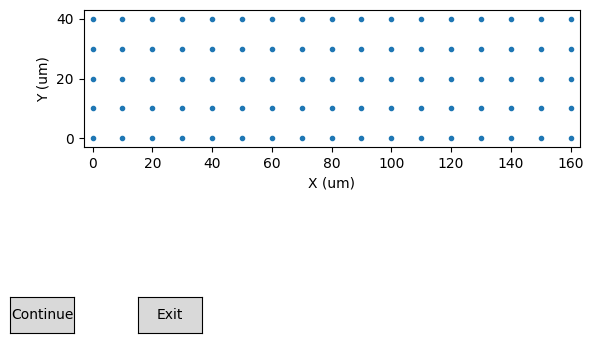

KeyboardInterrupt: 

In [11]:
ker = make_main(entangle_cols_low_dist, entangle_rows)

# matplotlib.use("TkAgg")  # requirement for PathVisualizer

PathVisualizer(ker.dialects, arch_spec=arch_spec).run(ker, ())